In [1]:
import ast
import gzip
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
import matplotlib.pyplot as plt

#### Heatmap of all the variants (unclustered)

In [2]:
### Plot a heatmap of values per position
delta_df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism.csv")

✅ Found suffix groups: ['wC', 'wL', 'wR']
Rows with wC: 41
Rows with wR: 41
Rows with wL: 41

Common id_prefix entries across all groups: 41
wC DataFrame length: 41
wL DataFrame length: 41
wR DataFrame length: 41
wC: ISM array length (per row): 200
wL: ISM array length (per row): 200
wR: ISM array length (per row): 200


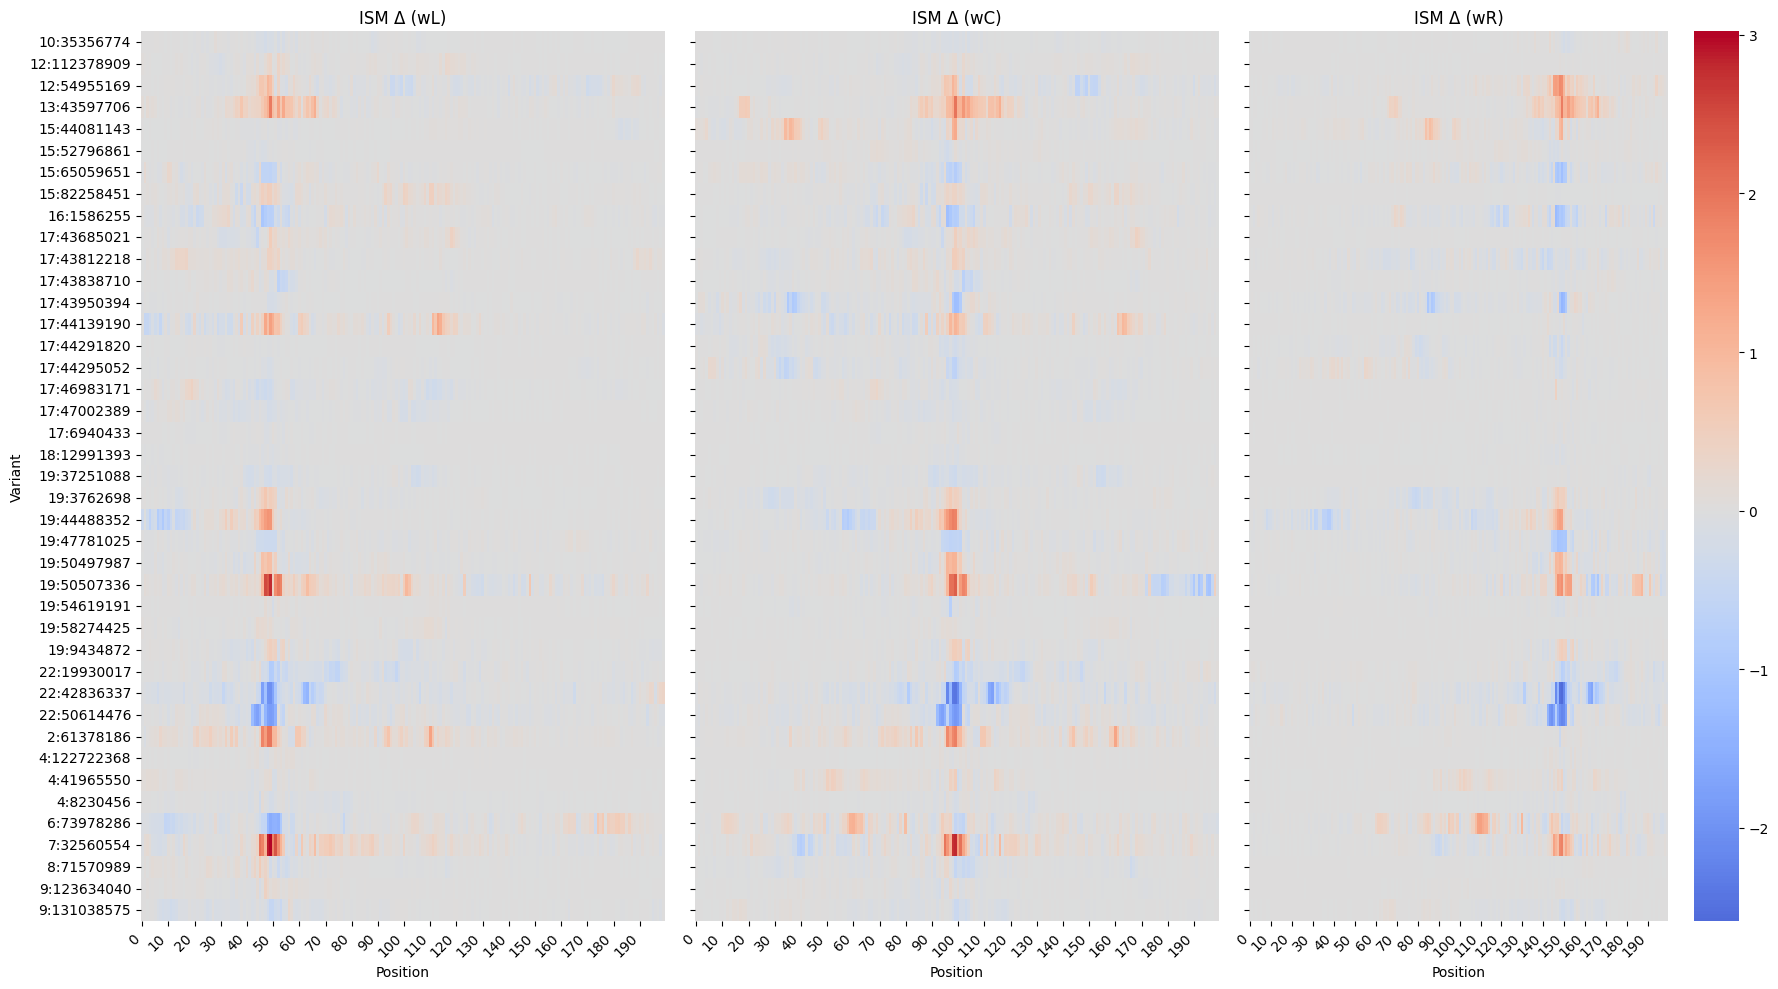

In [3]:
# Convert column to list of arrays if not already
ism_arrays = [np.array(ast.literal_eval(s)) for s in delta_df["ism"]]

# # Compute max per row
# row_maxes = [np.max(np.abs(arr)) for arr in ism_arrays]

row_maxes = np.ones(len(ism_arrays))

# # Normalize each row by its own max
delta_df["ism"] = [arr / m if m != 0 else arr for arr, m in zip(ism_arrays, row_maxes)]


import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Make sure base_id exists ---
assert "base_id" in delta_df.columns, "base_id column missing!"

# --- Split out parts of base_id ---
base_split = delta_df["base_id"].str.split(":")
delta_df["id_prefix"] = base_split.str[:2].str.join(":")   
delta_df["id_suffix"] = base_split.str[-1]                 

# delta_df = delta_df[delta_df["id_prefix"] == "17:44139190"]

# --- Filter only expected suffixes ---
valid_suffixes = ["wC", "wR", "wL"]
delta_df = delta_df[delta_df["id_suffix"].isin(valid_suffixes)]

# --- Check which suffixes exist ---
present_suffixes = sorted(delta_df["id_suffix"].unique())
print(f"✅ Found suffix groups: {present_suffixes}")

# --- Print counts per suffix ---
for suffix in valid_suffixes:
    count = (delta_df["id_suffix"] == suffix).sum()
    print(f"Rows with {suffix}: {count}")

# --- Ensure consistent ordering across suffixes ---
# keep only rows whose prefix appears in *all* three
prefix_sets = {
    suffix: set(delta_df.loc[delta_df["id_suffix"] == suffix, "id_prefix"])
    for suffix in present_suffixes
}
common_ids = set.intersection(*prefix_sets.values()) if len(prefix_sets) > 1 else set()

print(f"\nCommon id_prefix entries across all groups: {len(common_ids)}")

if not common_ids:
    raise ValueError("No common id_prefix entries across all wC/wR/wL groups.")

# --- Filter for common ids only ---
delta_df = delta_df[delta_df["id_prefix"].isin(common_ids)]

# --- Sort by id_prefix for consistent row order ---
delta_df = delta_df.sort_values(["id_prefix", "id_suffix"])

# --- Build dict of suffix→data ---
dfs = {
    suffix: delta_df[delta_df["id_suffix"] == suffix]
    for suffix in present_suffixes
}

# --- Print lengths of each df explicitly ---
for k, v in dfs.items():
    print(f"{k} DataFrame length: {len(v)}")

# --- Get row labels (same for all suffixes) ---
row_labels = dfs[present_suffixes[0]]["id_prefix"].tolist()

# --- Convert ISM column to consistent arrays ---
heatmaps = {}
for k, v in dfs.items():
    arr_list = v["ism"].tolist()
    max_len = max(len(a) for a in arr_list)
    print(f"{k}: ISM array length (per row): {max_len}")
    arr = np.array([np.pad(a, (0, max_len - len(a))) for a in arr_list])
    heatmaps[k] = arr


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Reorder so wC is in the middle ---
order = [s for s in ["wL", "wC", "wR"] if s in present_suffixes]
n = len(order)

# --- Shared color scale across all heatmaps ---
vmin = min(np.min(heatmaps[s]) for s in order)
vmax = max(np.max(heatmaps[s]) for s in order)

# --- Create subplots ---
fig, axes = plt.subplots(1, n, figsize=(18, 10), sharey=True)

# If only one suffix, axes won't be iterable
if n == 1:
    axes = [axes]

# --- Plot each heatmap ---
for i, suffix in enumerate(order):
    ax = axes[i]
    hm = sns.heatmap(
        heatmaps[suffix],
        cmap="coolwarm",
        center=0,
        vmin=vmin,
        vmax=vmax,
        xticklabels=10,
        yticklabels=row_labels, 
        cbar=(i == n - 1),  # only add colorbar on last plot
        ax=ax
    )

    # Axis/labels
    ax.set_title(f"ISM Δ ({suffix})")
    ax.set_xlabel("Position")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    if i == 0:
        ax.set_ylabel("Variant")
    else:
        ax.set_ylabel("")

# --- Adjust layout ---
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_one_variant.png")
plt.show()


In [4]:
delta_df

,Unnamed: 0,base_id,delta_predictions,ism,id_prefix,id_suffix
0,0,10:35356774:A:G:wC,"[{'C': -0.00046056509017944336, 'G': 0.0012556...","[0.00041673580805460614, 0.0012967387835184734...",10:35356774,wC
1,1,10:35356774:A:G:wL,"[{'A': 0.01563131809234619, 'C': 0.00525522232...","[0.012402892112731934, 0.010413845380147299, 0...",10:35356774,wL
2,2,10:35356774:A:G:wR,"[{'A': -0.0002966374158859253, 'C': -0.0015683...","[-0.003689602017402649, 0.0021815101305643716,...",10:35356774,wR
3,3,12:112378909:C:T:wC,"[{'A': 0.02187502384185791, 'C': -0.0073300600...","[0.012742042541503906, -0.015603462855021158, ...",12:112378909,wC
4,4,12:112378909:C:T:wL,"[{'A': 0.05443072319030762, 'C': 0.02598023414...","[0.0453027089436849, 0.036308606465657554, -0....",12:112378909,wL
...,...,...,...,...,...,...
118,118,9:123634040:G:A:wL,"[{'A': 0.0054934024810791016, 'G': 0.011078596...","[0.014496882756551107, 0.010021209716796875, 0...",9:123634040,wL
119,119,9:123634040:G:A:wR,"[{'A': 0.0005387067794799805, 'C': -0.00028473...","[-1.702706019083659e-05, -0.000829637050628662...",9:123634040,wR
120,120,9:131038575:G:C:wC,"[{'A': 0.0031647682189941406, 'G': 0.004302024...","[0.005362510681152344, 0.0017175674438476562, ...",9:131038575,wC
121,121,9:131038575:G:C:wL,"[{'A': 0.01330709457397461, 'C': 0.00984668731...","[0.01322313149770101, 0.012762626012166342, -0...",9:131038575,wL


#### Cluster the heatmap based on euclidean 

✅ Clustering complete, plotting heatmaps with clustered rows


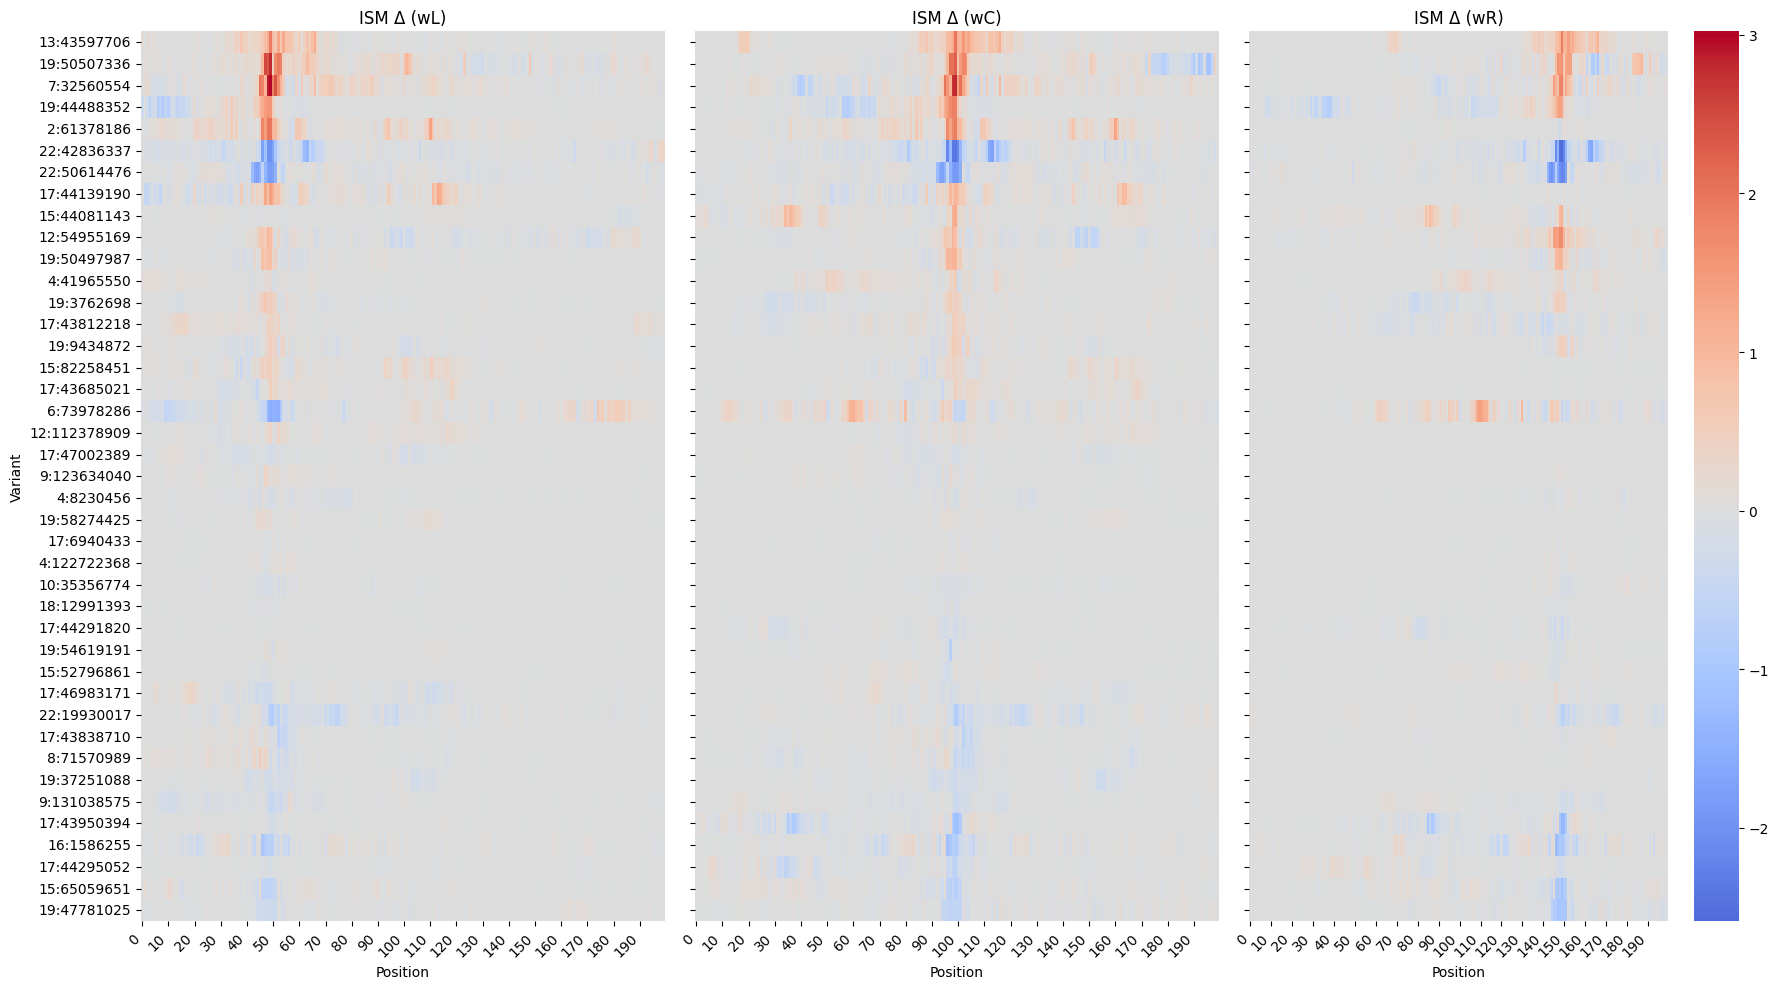

In [5]:
from scipy.cluster.hierarchy import linkage, leaves_list

# --- Use one suffix for clustering rows ---
# Here we'll use 'wC' if it exists, else pick the first suffix
cluster_suffix = "wC" if "wC" in heatmaps else present_suffixes[0]
arr_to_cluster = heatmaps[cluster_suffix]

# --- Perform hierarchical clustering on rows ---
# Use Euclidean distance and Ward linkage
row_linkage = linkage(arr_to_cluster, method='ward', metric='euclidean')
# Get the new row order
row_order = leaves_list(row_linkage)

# --- Reorder heatmaps and row labels according to clustering ---
for suffix in heatmaps:
    heatmaps[suffix] = heatmaps[suffix][row_order]
row_labels = [row_labels[i] for i in row_order]

print(f"✅ Clustering complete, plotting heatmaps with clustered rows")

fig, axes = plt.subplots(1, n, figsize=(18, 10), sharey=True)
if n == 1:
    axes = [axes]

for i, suffix in enumerate(order):
    ax = axes[i]
    sns.heatmap(
        heatmaps[suffix],
        cmap="coolwarm",
        center=0,
        vmin=vmin,
        vmax=vmax,
        xticklabels=10,
        yticklabels=row_labels,
        cbar=(i == n - 1),
        ax=ax
    )
    ax.set_title(f"ISM Δ ({suffix})")
    ax.set_xlabel("Position")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    if i == 0:
        ax.set_ylabel("Variant")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_one_variant_clustered.png")
plt.show()



#### Heatmap clustered by |ISM|

✅ Rows clustered by |ISM| values (sign ignored).


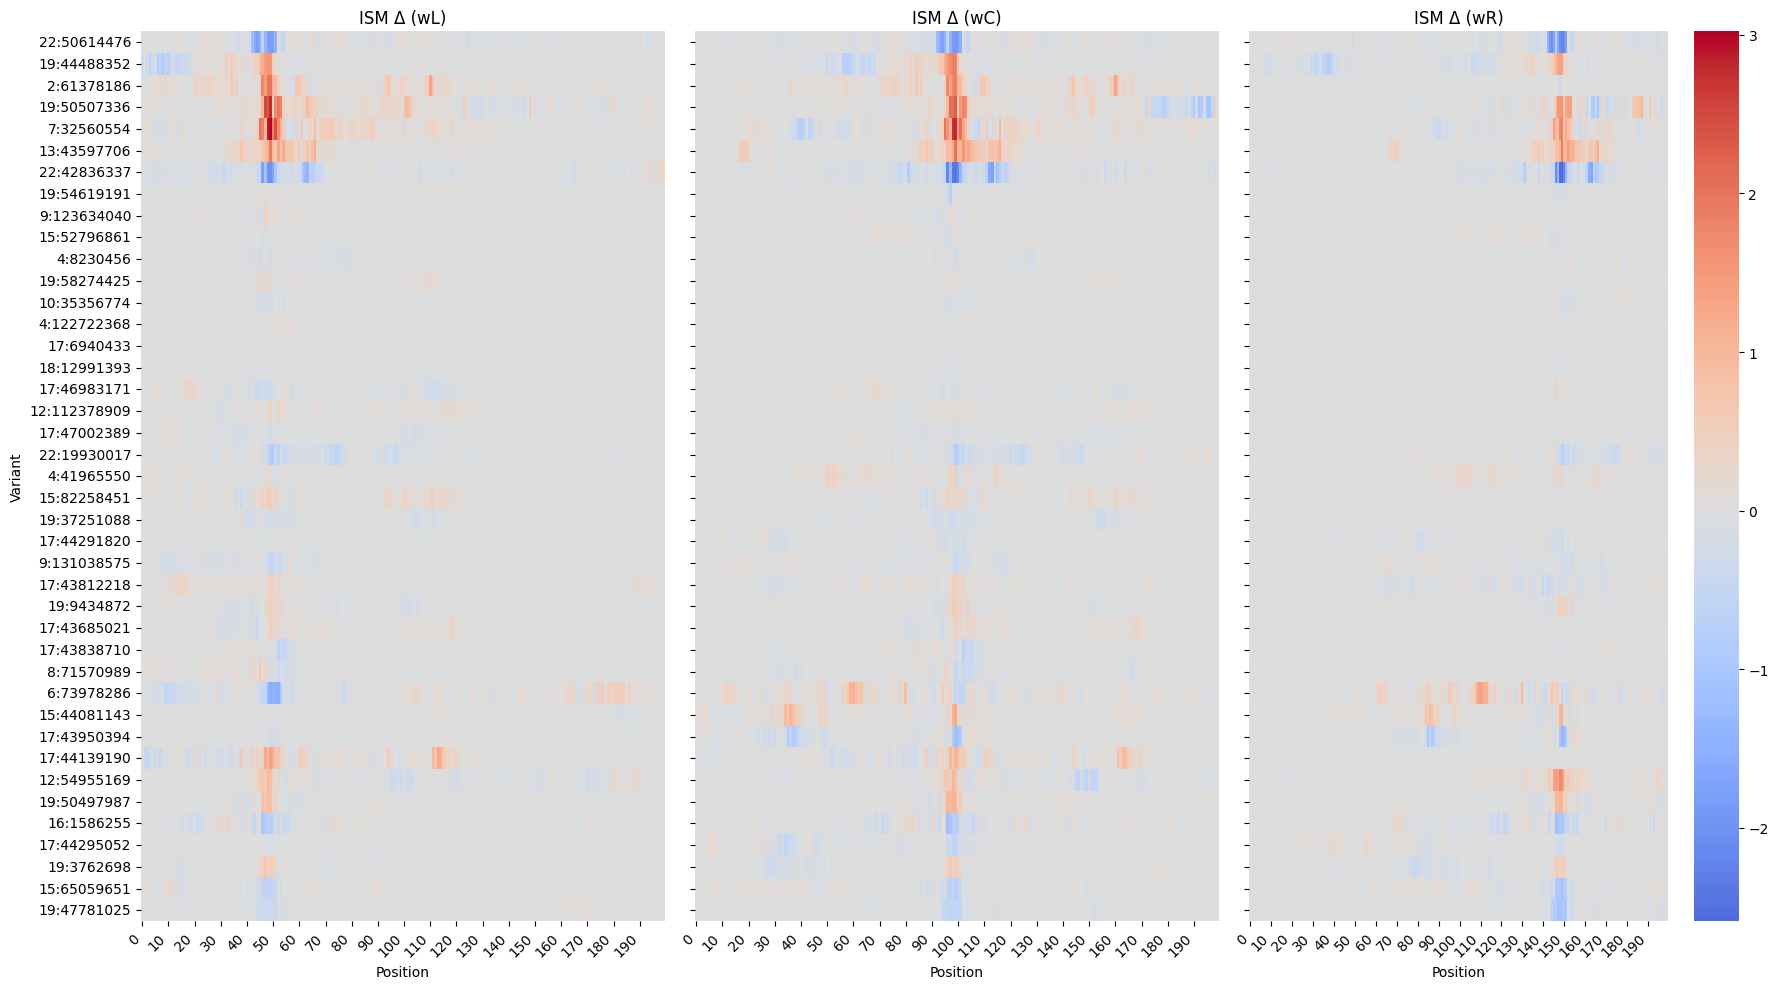

In [6]:
from scipy.cluster.hierarchy import linkage, leaves_list
import numpy as np

# Pick a suffix to base clustering on (here 'wC' if it exists)
cluster_suffix = "wC" if "wC" in heatmaps else present_suffixes[0]

# Take absolute values of each row to ignore sign
arr_to_cluster = np.abs(heatmaps[cluster_suffix])  # shape: (num_rows, num_positions)

# Hierarchical clustering on rows
row_linkage = linkage(arr_to_cluster, method='ward', metric='euclidean')

# Get new row order
row_order = leaves_list(row_linkage)

# Reorder heatmaps and row_labels
for suffix in heatmaps:
    heatmaps[suffix] = heatmaps[suffix][row_order]
row_labels = [row_labels[i] for i in row_order]

print("✅ Rows clustered by |ISM| values (sign ignored).")

fig, axes = plt.subplots(1, n, figsize=(18, 10), sharey=True)
if n == 1:
    axes = [axes]

for i, suffix in enumerate(order):
    ax = axes[i]
    sns.heatmap(
        heatmaps[suffix],
        cmap="coolwarm",
        center=0,
        vmin=vmin,
        vmax=vmax,
        xticklabels=10,
        yticklabels=row_labels,
        cbar=(i == n - 1),
        ax=ax
    )
    ax.set_title(f"ISM Δ ({suffix})")
    ax.set_xlabel("Position")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    if i == 0:
        ax.set_ylabel("Variant")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_one_variant_clustered.png")
plt.show()




#### Clustered by |ISM|, make the site of variant effect no value

✅ Rows clustered by |ISM| values (sign ignored).
Plotting only suffix: wC


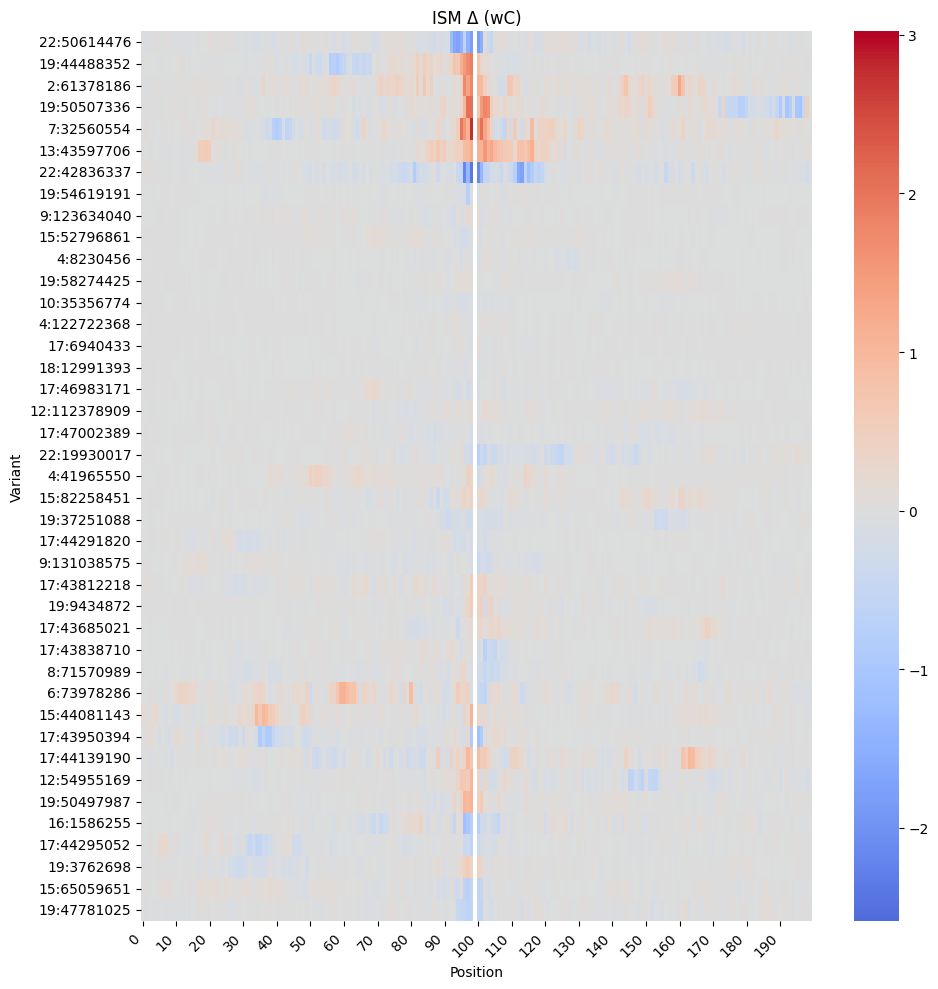

In [7]:
from scipy.cluster.hierarchy import linkage, leaves_list
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Choose suffix
cluster_suffix = "wC" if "wC" in heatmaps else present_suffixes[0]

# Cluster rows based on |ISM|
arr_to_cluster = np.abs(heatmaps[cluster_suffix])
row_linkage = linkage(arr_to_cluster, method='ward', metric='euclidean')
row_order = leaves_list(row_linkage)

# Reorder the heatmap and labels
heatmap_wc = heatmaps[cluster_suffix][row_order]
row_labels = [row_labels[i] for i in row_order]

# Make position 100 white (set to NaN)
if heatmap_wc.shape[1] > 99:  # make sure column exists
    heatmap_wc[:, 99] = np.nan

print("✅ Rows clustered by |ISM| values (sign ignored).")
print(f"Plotting only suffix: {cluster_suffix}")

# Create a copy of your colormap with NaN shown as white
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color='white')

# Plot only the wC heatmap
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    heatmap_wc,
    cmap=cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels=row_labels,
    cbar=True,
    ax=ax
)
ax.set_title(f"ISM Δ ({cluster_suffix})")
ax.set_xlabel("Position")
ax.set_ylabel("Variant")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_one_variant_clustered_wC_masked.png")
plt.show()


### Scaling the ISM by variant effect

In [8]:
### Here I will scale up by the variant effect
import pandas as pd

# Load data
predicted_mean = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/1-GTeX_experimental_variant_effect/predicted_mean.txt")

# Split seq_id into components
cols = ["chrom", "pos", "ref", "alt", "allele", "suffix"]
predicted_mean[cols] = predicted_mean["seq_id"].str.split(":", expand=True)

# Create base_id (without the allele)
predicted_mean["base_id"] = predicted_mean.apply(
    lambda x: f"{x['chrom']}:{x['pos']}:{x['ref']}:{x['alt']}:{x['suffix']}", axis=1
)

# Pivot to have rows = variant, columns = allele (R or A)
pivot = predicted_mean.pivot_table(
    index=["chrom", "pos", "ref", "alt", "suffix", "base_id"],
    columns="allele",
    values="prediction"
).reset_index()

# Compute variant effect:
pivot["variant_effect"] = pivot["R"] - pivot["A"]
filtered_variants = pivot[(pivot["variant_effect"] > 0.5) | (pivot["variant_effect"] < -0.5)]


pivot.head()



allele,chrom,pos,ref,alt,suffix,base_id,A,R,variant_effect
0,10,35356774,A,G,wC,10:35356774:A:G:wC,1.311615,1.034276,-0.277338
1,10,35356774,A,G,wL,10:35356774:A:G:wL,1.738686,1.187440,-0.551247
2,10,35356774,A,G,wR,10:35356774:A:G:wR,0.145187,0.026988,-0.118198
3,12,112378909,C,T,wC,12:112378909:C:T:wC,1.585935,1.748089,0.162155
4,12,112378909,C,T,wL,12:112378909:C:T:wL,1.386829,1.565720,0.178891


In [9]:
### Plot a heatmap of values per position
delta_df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism.csv")

In [10]:
merged = pd.merge(delta_df,filtered_variants, on="base_id", how="inner")

In [11]:
merged["ism_array"] = merged["ism"].apply(ast.literal_eval)

# Now divide by variant_effect
merged["ism_normed"] = merged.apply(lambda row: np.array(row["ism_array"]) / row["variant_effect"], axis=1)

print(merged["ism"])
print(merged["ism_normed"])
print(merged["variant_effect"])

0     [0.012402892112731934, 0.010413845380147299, 0...
1     [0.019878307978312176, -0.005778392155965169, ...
2     [0.014422257741292318, 0.0019336541493733723, ...
3     [0.010767380396525065, -0.001840670903523763, ...
4     [0.09309995174407959, 0.0697319507598877, 0.08...
5     [-0.0003465016682942708, 0.0002539555231730143...
6     [0.016036033630371094, 0.02562562624613444, 0....
7     [-0.033998784919579826, 0.21007738262414932, 0...
8     [0.019512414932250977, -0.022376457850138348, ...
9     [-0.0026886463165283203, -0.015768925348917644...
10    [0.024884402751922607, -0.03542164961496989, -...
11    [0.003141045570373535, -0.01966993014017741, -...
12    [-0.0027524630228678384, -0.014277299245198568...
13    [-0.023117899894714355, 0.0008407433827718099,...
14    [-0.021516700585683186, 0.08648745218912761, 0...
15    [0.019120971361796062, 0.026830315589904785, 0...
16    [-0.06120244848231474, -0.02511514847477277, -...
17    [0.013058605293432871, -0.523078590631485,

✅ Found suffix groups: ['wC', 'wL', 'wR']
Rows with wC: 18
Rows with wR: 16
Rows with wL: 17

Common id_prefix entries across all groups: 11
wC DataFrame length: 11
wL DataFrame length: 11
wR DataFrame length: 11
wC: ISM array length (per row): 200
wL: ISM array length (per row): 200
wR: ISM array length (per row): 200


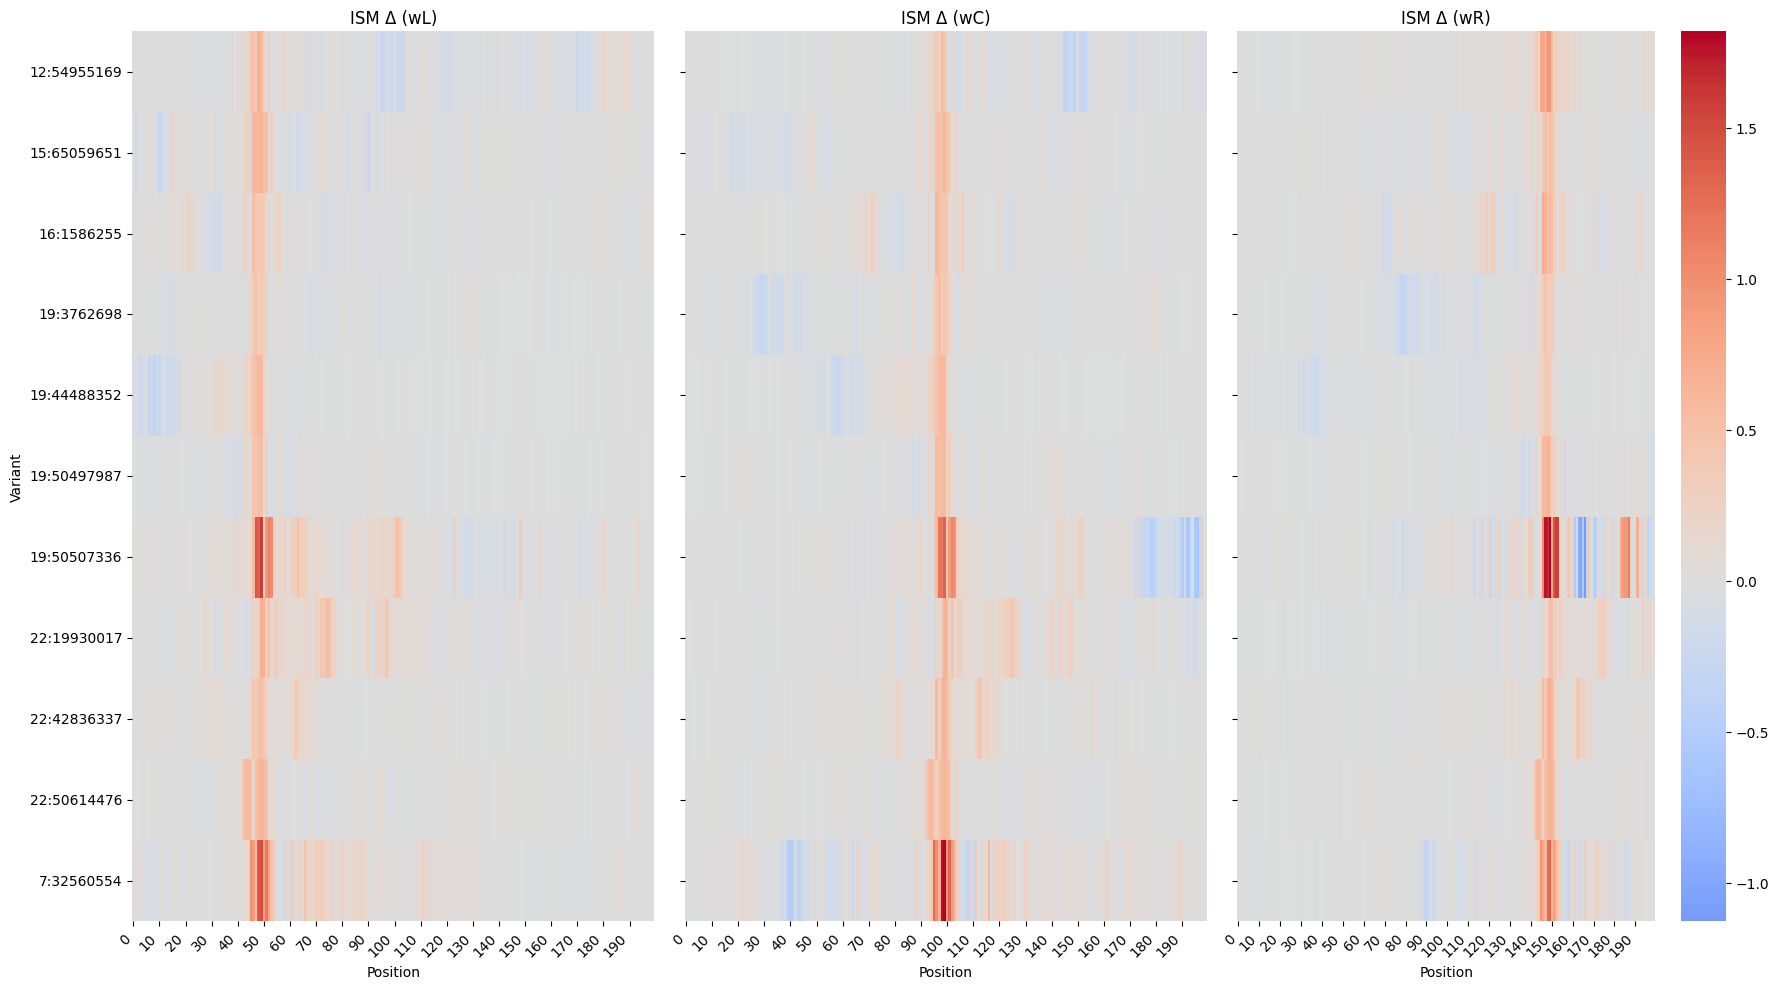

In [12]:
# ism_arrays = [np.array(ast.literal_eval(s)) for s in merged["ism_normed"]]

# # Compute max per row
# row_maxes = [np.max(np.abs(arr)) for arr in ism_arrays]

row_maxes = np.ones(len(ism_arrays))

# # Normalize each row by its own max
# merged["ism_normed"] = [arr / m if m != 0 else arr for arr, m in zip(ism_arrays, row_maxes)]


import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Make sure base_id exists ---
assert "base_id" in merged.columns, "base_id column missing!"

# --- Split out parts of base_id ---
base_split = merged["base_id"].str.split(":")
merged["id_prefix"] = base_split.str[:2].str.join(":")   
merged["id_suffix"] = base_split.str[-1]                 

# merged = merged[merged["id_prefix"] == "17:44139190"]

# --- Filter only expected suffixes ---
valid_suffixes = ["wC", "wR", "wL"]
merged = merged[merged["id_suffix"].isin(valid_suffixes)]

# --- Check which suffixes exist ---
present_suffixes = sorted(merged["id_suffix"].unique())
print(f"✅ Found suffix groups: {present_suffixes}")

# --- Print counts per suffix ---
for suffix in valid_suffixes:
    count = (merged["id_suffix"] == suffix).sum()
    print(f"Rows with {suffix}: {count}")

# --- Ensure consistent ordering across suffixes ---
# keep only rows whose prefix appears in *all* three
prefix_sets = {
    suffix: set(merged.loc[merged["id_suffix"] == suffix, "id_prefix"])
    for suffix in present_suffixes
}
common_ids = set.intersection(*prefix_sets.values()) if len(prefix_sets) > 1 else set()

print(f"\nCommon id_prefix entries across all groups: {len(common_ids)}")

if not common_ids:
    raise ValueError("No common id_prefix entries across all wC/wR/wL groups.")

# --- Filter for common ids only ---
merged = merged[merged["id_prefix"].isin(common_ids)]

# --- Sort by id_prefix for consistent row order ---
merged = merged.sort_values(["id_prefix", "id_suffix"])

# --- Build dict of suffix→data ---
dfs = {
    suffix: merged[merged["id_suffix"] == suffix]
    for suffix in present_suffixes
}

# --- Print lengths of each df explicitly ---
for k, v in dfs.items():
    print(f"{k} DataFrame length: {len(v)}")

# --- Get row labels (same for all suffixes) ---
row_labels = dfs[present_suffixes[0]]["id_prefix"].tolist()

# --- Convert ISM column to consistent arrays ---
heatmaps = {}
for k, v in dfs.items():
    arr_list = v["ism_normed"].tolist()
    max_len = max(len(a) for a in arr_list)
    print(f"{k}: ISM array length (per row): {max_len}")
    arr = np.array([np.pad(a, (0, max_len - len(a))) for a in arr_list])
    heatmaps[k] = arr


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Reorder so wC is in the middle ---
order = [s for s in ["wL", "wC", "wR"] if s in present_suffixes]
n = len(order)

# --- Shared color scale across all heatmaps ---
vmin = min(np.min(heatmaps[s]) for s in order)
vmax = max(np.max(heatmaps[s]) for s in order)

# --- Create subplots ---
fig, axes = plt.subplots(1, n, figsize=(18, 10), sharey=True)

# If only one suffix, axes won't be iterable
if n == 1:
    axes = [axes]

# --- Plot each heatmap ---
for i, suffix in enumerate(order):
    ax = axes[i]
    hm = sns.heatmap(
        heatmaps[suffix],
        cmap="coolwarm",
        center=0,
        vmin=vmin,
        vmax=vmax,
        xticklabels=10,
        yticklabels=row_labels, 
        cbar=(i == n - 1),  # only add colorbar on last plot
        ax=ax
    )

    # Axis/labels
    ax.set_title(f"ISM Δ ({suffix})")
    ax.set_xlabel("Position")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    if i == 0:
        ax.set_ylabel("Variant")
    else:
        ax.set_ylabel("")

# --- Adjust layout ---
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_scaled.png")
plt.show()


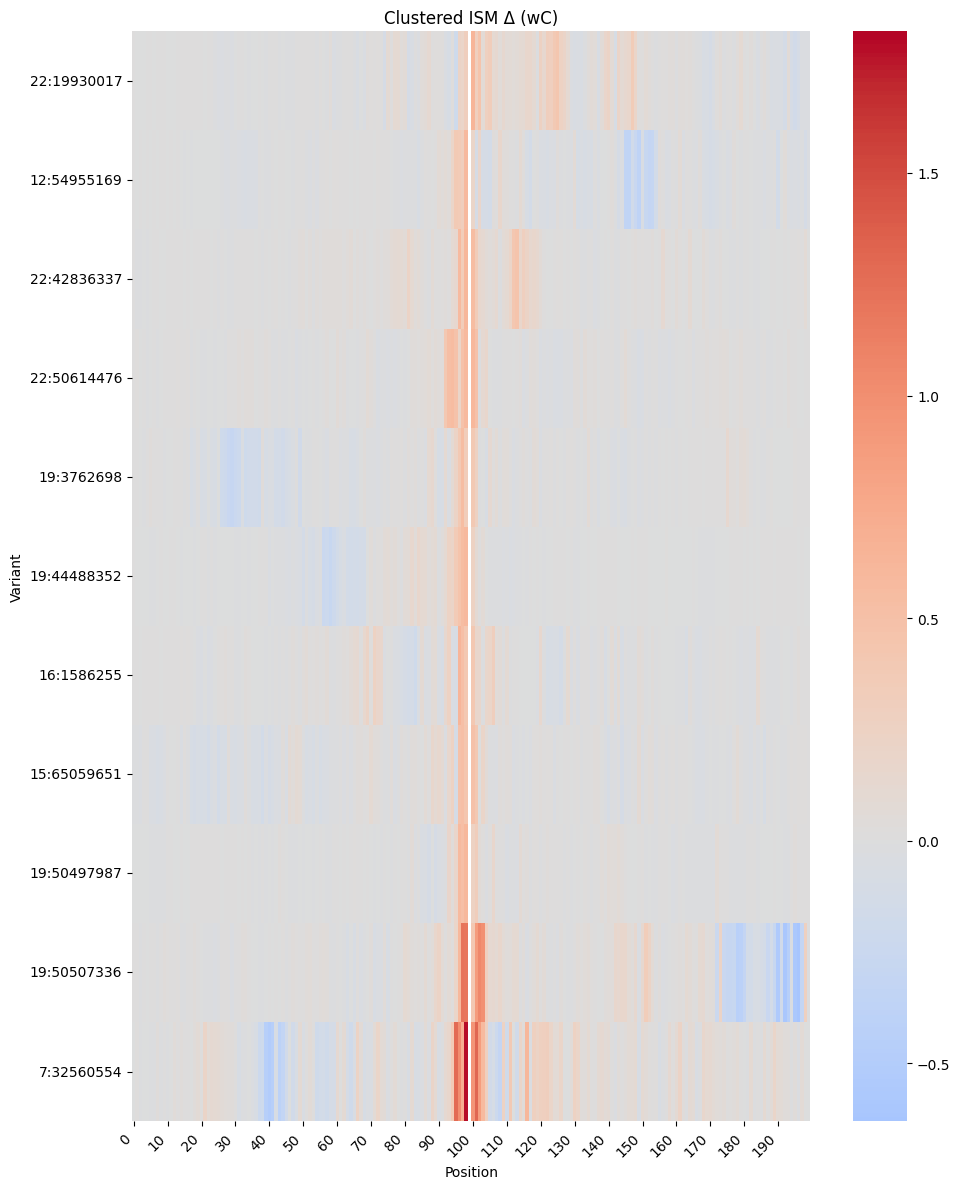

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

# --- Filter for wC only ---

wC_df = merged[merged["id_suffix"] == "wC"]
row_labels = wC_df["id_prefix"].tolist()

# --- Convert ISM column to arrays ---
ism_arrays = [np.array(a, dtype=float) for a in wC_df["ism_normed"]]
# ism_arrays = [np.array(ast.literal_eval(s)) for s in wC_df["ism_normed"]]
max_len = max(len(a) for a in ism_arrays)
heatmap_array = np.array([np.pad(a, (0, max_len - len(a))) for a in ism_arrays])

# --- Cluster rows by absolute ISM values ---
row_linkage = linkage(np.abs(heatmap_array), method='ward', metric='euclidean')
row_order = leaves_list(row_linkage)
heatmap_array = heatmap_array[row_order]
row_labels = [row_labels[i] for i in row_order]

# --- Mask the 99th position (0-based, i.e., 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
mask[:, 99] = True  # mask that column

# --- Shared color scale ---
vmin, vmax = np.min(heatmap_array), np.max(heatmap_array)

# --- Plot heatmap ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap="coolwarm",
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels=row_labels,
    mask=mask,  
    cbar=True
)
plt.title("Clustered ISM Δ (wC)")
plt.xlabel("Position")
plt.ylabel("Variant")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_wC_clustered_masked.png")
plt.show()
